# Power Flow Experiments & Paper Figures

Self-contained notebook. **No other files needed** - the Newton-Raphson solver is
embedded below, so you don't need `nr_solver.py` sitting next to this.

**Requires:** `numpy`, `matplotlib`, `networkx`

```
py -m pip install numpy matplotlib networkx
```

Run cells top to bottom (Cell -> Run All). Sections:

1. Solver (embedded)
2. Test network + helpers
3. Base case
4. Experiments 1-12
5. **Figure 1** - base case network heatmap
6. **Figure 2** - nose curve + Jacobian singularity + convergence
7. Bonus figures

## 1. Imports

In [1]:
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import networkx as nx

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 2. The solver (embedded)

This is `nr_solver.py` inlined so the notebook stands alone. Three classes:
`Bus` (a node), `Branch` (a line), and `PowerFlowNetwork` (builds Ybus and runs
Newton-Raphson).

In [2]:
class Bus:
    """A single network bus."""
    def __init__(self, bus_id, name, bus_type, Pd=0.0, Qd=0.0,
                 Pg=0.0, Vset=1.0, Qmin=None, Qmax=None,
                 x=None, y=None):
        """
        bus_id   : integer index (0-based) used internally
        name     : human-readable label
        bus_type : 'slack', 'PV', or 'PQ'
        Pd, Qd   : load demand (p.u.) at this bus
        Pg       : scheduled generation (p.u.) - only meaningful for PV/slack
        Vset     : voltage setpoint (p.u.) - for PV/slack buses
        Qmin/Qmax: reactive power limits for PV buses (p.u.), optional
        x, y     : optional plotting coordinates
        """
        self.id = bus_id
        self.name = name
        self.type = bus_type
        self.Pd = Pd
        self.Qd = Qd
        self.Pg = Pg
        self.Vset = Vset
        self.Qmin = Qmin
        self.Qmax = Qmax
        self.x = x
        self.y = y

        # Net specified injections (generation - load), in p.u.
        self.P_spec = Pg - Pd
        self.Q_spec = -Qd  # Q generation unspecified for PQ/PV until solved

        # Solution results (filled in after solve)
        self.V = Vset
        self.theta = 0.0
        self.P_calc = None
        self.Q_calc = None


class Branch:
    """A transmission line or transformer between two buses (pi-model)."""
    def __init__(self, from_bus, to_bus, r, x, b=0.0, tap=1.0, name=None):
        """
        from_bus, to_bus : bus indices (0-based)
        r, x  : series resistance / reactance in p.u.
        b     : total line charging susceptance in p.u. (shunt, split B/2 each end)
        tap   : off-nominal tap ratio (1.0 = no transformer)
        """
        self.f = from_bus
        self.t = to_bus
        self.r = r
        self.x = x
        self.b = b
        self.tap = tap if tap else 1.0
        self.name = name or f"{from_bus}-{to_bus}"
        z = complex(r, x)
        self.y_series = 1.0 / z if abs(z) > 0 else complex(0, 0)


class PowerFlowNetwork:
    """Container for buses + branches; builds Ybus and runs Newton-Raphson."""

    def __init__(self, name="Network", base_mva=100.0):
        self.name = name
        self.base_mva = base_mva
        self.buses = []
        self.branches = []
        self.Ybus = None

    # ------------------------------------------------------------------
    def add_bus(self, **kwargs):
        bus_id = len(self.buses)
        bus = Bus(bus_id, **kwargs)
        self.buses.append(bus)
        return bus

    def add_branch(self, from_bus, to_bus, r, x, b=0.0, tap=1.0, name=None):
        branch = Branch(from_bus, to_bus, r, x, b, tap, name)
        self.branches.append(branch)
        return branch

    # ------------------------------------------------------------------
    def build_ybus(self):
        n = len(self.buses)
        Y = np.zeros((n, n), dtype=complex)
        for br in self.branches:
            f, t = br.f, br.t
            ys = br.y_series
            bc = br.b / 2.0  # half-line charging at each end
            tap = br.tap

            # Standard pi-model with off-nominal tap (tap on the 'from' side)
            Y[f, f] += (ys + 1j * bc) / (tap ** 2)
            Y[t, t] += (ys + 1j * bc)
            Y[f, t] -= ys / tap
            Y[t, f] -= ys / tap
        self.Ybus = Y
        return Y

    # ------------------------------------------------------------------
    def _classify(self):
        slack_idx = [b.id for b in self.buses if b.type == 'slack']
        pv_idx = [b.id for b in self.buses if b.type == 'PV']
        pq_idx = [b.id for b in self.buses if b.type == 'PQ']
        if len(slack_idx) != 1:
            raise ValueError(f"Exactly one slack bus required, found {len(slack_idx)}")
        return slack_idx[0], pv_idx, pq_idx

    # ------------------------------------------------------------------
    def solve(self, tol=1e-8, max_iter=30, verbose=True, flat_start=True):
        """
        Runs Newton-Raphson power flow. Returns a dict with convergence info
        and per-bus results. Also stores results back onto each Bus object.
        """
        if self.Ybus is None:
            self.build_ybus()

        n = len(self.buses)
        G = self.Ybus.real
        B = self.Ybus.imag

        slack, pv_idx, pq_idx = self._classify()
        pv_pq = sorted(pv_idx + pq_idx)   # buses needing theta update
        pq = sorted(pq_idx)               # buses needing V update

        # --- initialize state vectors (flat start unless told otherwise) ---
        V = np.array([b.Vset if b.type != 'PQ' else 1.0 for b in self.buses], dtype=float)
        theta = np.zeros(n)
        if not flat_start:
            V = np.array([b.V for b in self.buses], dtype=float)
            theta = np.array([b.theta for b in self.buses], dtype=float)

        # Specified P, Q at each bus (p.u.)
        P_spec = np.array([b.P_spec for b in self.buses], dtype=float)
        Q_spec = np.array([b.Q_spec for b in self.buses], dtype=float)

        history = []

        def calc_PQ(V, theta):
            P = np.zeros(n)
            Q = np.zeros(n)
            for i in range(n):
                for k in range(n):
                    ang = theta[i] - theta[k]
                    P[i] += V[i] * V[k] * (G[i, k] * np.cos(ang) + B[i, k] * np.sin(ang))
                    Q[i] += V[i] * V[k] * (G[i, k] * np.sin(ang) - B[i, k] * np.cos(ang))
            return P, Q

        converged = False
        n_iter = 0

        for it in range(1, max_iter + 1):
            P_calc, Q_calc = calc_PQ(V, theta)

            # Mismatch vectors (only for relevant bus subsets)
            dP = P_spec[pv_pq] - P_calc[pv_pq]
            dQ = Q_spec[pq] - Q_calc[pq]
            mismatch = np.concatenate([dP, dQ])
            max_mismatch = np.max(np.abs(mismatch)) if mismatch.size else 0.0
            history.append(max_mismatch)

            if verbose:
                print(f"  Iter {it:2d}: max mismatch = {max_mismatch:.3e}")

            if max_mismatch < tol:
                converged = True
                n_iter = it - 1
                break

            # ---------------- Build the Jacobian ----------------
            npv_pq = len(pv_pq)
            npq = len(pq)
            J11 = np.zeros((npv_pq, npv_pq))  # dP/dtheta
            J12 = np.zeros((npv_pq, npq))     # dP/dV
            J21 = np.zeros((npq, npv_pq))     # dQ/dtheta
            J22 = np.zeros((npq, npq))        # dQ/dV

            idx_map_pvpq = {bus: k for k, bus in enumerate(pv_pq)}
            idx_map_pq = {bus: k for k, bus in enumerate(pq)}

            for a, i in enumerate(pv_pq):
                for b_, k in enumerate(pv_pq):
                    if i == k:
                        J11[a, b_] = -Q_calc[i] - B[i, i] * V[i] ** 2
                    else:
                        ang = theta[i] - theta[k]
                        J11[a, b_] = V[i] * V[k] * (G[i, k] * np.sin(ang) - B[i, k] * np.cos(ang))

                for b_, k in enumerate(pq):
                    if i == k:
                        J12[a, b_] = P_calc[i] / V[i] + G[i, i] * V[i]
                    else:
                        ang = theta[i] - theta[k]
                        J12[a, b_] = V[i] * (G[i, k] * np.cos(ang) + B[i, k] * np.sin(ang))

            for a, i in enumerate(pq):
                for b_, k in enumerate(pv_pq):
                    if i == k:
                        J21[a, b_] = P_calc[i] - G[i, i] * V[i] ** 2
                    else:
                        ang = theta[i] - theta[k]
                        J21[a, b_] = -V[i] * V[k] * (G[i, k] * np.cos(ang) + B[i, k] * np.sin(ang))

                for b_, k in enumerate(pq):
                    if i == k:
                        J22[a, b_] = Q_calc[i] / V[i] - B[i, i] * V[i]
                    else:
                        ang = theta[i] - theta[k]
                        J22[a, b_] = V[i] * (G[i, k] * np.sin(ang) - B[i, k] * np.cos(ang))

            J = np.block([[J11, J12], [J21, J22]])

            try:
                dx = np.linalg.solve(J, mismatch)
            except np.linalg.LinAlgError as e:
                raise RuntimeError(f"Jacobian is singular at iteration {it}: {e}")

            dtheta = dx[:npv_pq]
            dV = dx[npv_pq:]

            for a, i in enumerate(pv_pq):
                theta[i] += dtheta[a]
            for a, i in enumerate(pq):
                V[i] += dV[a]

            n_iter = it

        # Final power calc (also gets slack + PV bus Q/P actuals)
        P_calc, Q_calc = calc_PQ(V, theta)

        # Write results back to bus objects
        for b in self.buses:
            b.V = V[b.id]
            b.theta = theta[b.id]
            b.P_calc = P_calc[b.id]
            b.Q_calc = Q_calc[b.id]

        result = {
            "converged": converged,
            "iterations": n_iter,
            "mismatch_history": history,
            "V": V,
            "theta": theta,
            "theta_deg": np.degrees(theta),
            "P_calc": P_calc,
            "Q_calc": Q_calc,
        }
        return result

    # ------------------------------------------------------------------
    def branch_flows(self):
        """Compute real/reactive power flow (p.u.) leaving each branch on
        both ends, and the resulting losses, using solved V/theta."""
        flows = []
        Vc = np.array([b.V * np.exp(1j * b.theta) for b in self.buses])
        for br in self.branches:
            f, t = br.f, br.t
            ys = br.y_series
            bc = br.b / 2.0
            tap = br.tap

            Vf, Vt = Vc[f], Vc[t]
            # Current from f->t and t->f (pi model with tap on 'from' side)
            I_ft = (ys + 1j * bc) / (tap ** 2) * Vf - (ys / tap) * Vt
            I_tf = (ys + 1j * bc) * Vt - (ys / tap) * Vf

            S_ft = Vf * np.conj(I_ft)
            S_tf = Vt * np.conj(I_tf)
            loss = S_ft + S_tf  # complex power loss on the branch

            flows.append({
                "name": br.name,
                "from": self.buses[f].name,
                "to": self.buses[t].name,
                "P_ft": S_ft.real, "Q_ft": S_ft.imag,
                "P_tf": S_tf.real, "Q_tf": S_tf.imag,
                "P_loss": loss.real, "Q_loss": loss.imag,
            })
        return flows

    # ------------------------------------------------------------------
    def summary_table(self):
        """Return a list of dicts describing the solved state of each bus,
        in engineering units (MW / MVAr) as well as p.u."""
        rows = []
        for b in self.buses:
            rows.append({
                "Bus": b.name,
                "Type": b.type,
                "V_pu": b.V,
                "Angle_deg": np.degrees(b.theta),
                "P_MW": b.P_calc * self.base_mva,
                "Q_MVAr": b.Q_calc * self.base_mva,
                "Pd_MW": b.Pd * self.base_mva,
                "Qd_MW": b.Qd * self.base_mva,
            })
        return rows

## 3. Test network + helpers

`base_network()` builds the 7-bus system and accepts **patches**, which is what makes
every experiment a two-liner:

```python
base_network(bus={3: dict(Pd=1.60)})           # change bus 3's load
base_network(branch={"L1-4": dict(x=0.240)})   # change a line's reactance
base_network(drop_branch="L1-4")               # remove a line entirely
```

In [3]:
def base_network(**overrides):
    """Build the 7-bus base case. overrides can patch bus/branch params."""
    bus_over = overrides.get("bus", {})
    br_over = overrides.get("branch", {})
    drop = overrides.get("drop_branch", None)

    net = PowerFlowNetwork(name="7-Bus", base_mva=100.0)
    buses = [
        dict(name="Bus 1 (Slack)", bus_type="slack", Vset=1.04, x=0, y=1),
        dict(name="Bus 2 (Gen)", bus_type="PV", Pg=0.60, Vset=1.03, x=1, y=2),
        dict(name="Bus 3 (Load)", bus_type="PQ", Pd=0.55, Qd=0.13, x=2, y=2),
        dict(name="Bus 4 (Load)", bus_type="PQ", Pd=0.80, Qd=0.30, x=1, y=1),
        dict(name="Bus 5 (Load)", bus_type="PQ", Pd=0.40, Qd=0.10, x=2, y=0),
        dict(name="Bus 6 (Gen)", bus_type="PV", Pg=0.70, Vset=1.02, x=0, y=0),
        dict(name="Bus 7 (Load)", bus_type="PQ", Pd=0.35, Qd=0.09, x=1, y=0),
    ]
    for i, b in enumerate(buses):
        b.update(bus_over.get(i, {}))
        net.add_bus(**b)

    branches = [
        dict(from_bus=0, to_bus=1, r=0.010, x=0.070, b=0.020, name="L1-2"),
        dict(from_bus=1, to_bus=2, r=0.015, x=0.090, b=0.025, name="L2-3"),
        dict(from_bus=0, to_bus=3, r=0.012, x=0.080, b=0.022, name="L1-4"),
        dict(from_bus=2, to_bus=3, r=0.014, x=0.085, b=0.020, name="L3-4"),
        dict(from_bus=3, to_bus=4, r=0.018, x=0.100, b=0.028, name="L4-5"),
        dict(from_bus=0, to_bus=5, r=0.011, x=0.075, b=0.021, name="L1-6"),
        dict(from_bus=5, to_bus=6, r=0.016, x=0.095, b=0.024, name="L6-7"),
        dict(from_bus=4, to_bus=6, r=0.013, x=0.082, b=0.023, name="L5-7"),
    ]
    for i, br in enumerate(branches):
        if drop is not None and br["name"] == drop:
            continue
        br.update(br_over.get(br["name"], {}))
        net.add_branch(**br)
    return net


def run(net, tol=1e-8, max_iter=30, flat_start=True):
    """Solve quietly and return the result dict."""
    with contextlib.redirect_stdout(io.StringIO()):
        res = net.solve(tol=tol, max_iter=max_iter, verbose=False, flat_start=flat_start)
    return res


def vrow(net):
    return [f"{b.V:.4f}" for b in net.buses]

def losses(net):
    return sum(f["P_loss"] for f in net.branch_flows()) * 100

def slack_P(net):
    return net.buses[0].P_calc * 100

def flow(net, name):
    return [f for f in net.branch_flows() if f["name"] == name][0]

HDR = ["B1", "B2", "B3", "B4", "B5", "B6", "B7"]
print("helpers ready")

helpers ready


## 4. Base case

In [4]:
net = base_network()
res = run(net)
print("iters:", res["iterations"], "| converged:", res["converged"])
print("V:", dict(zip(HDR, vrow(net))))
print(f"Slack P: {slack_P(net):.2f} MW | Total losses: {losses(net):.3f} MW")
print("Q at PV buses (MVAr):",
      f"B2={net.buses[1].Q_calc*100:.2f}", f"B6={net.buses[5].Q_calc*100:.2f}")

# power balance check
tot_gen = sum(b.P_calc for b in net.buses if b.type in ('slack','PV')) * 100
tot_load = sum(b.Pd for b in net.buses) * 100
print(f"\nBalance: gen {tot_gen:.3f} - load {tot_load:.3f} - loss {losses(net):.3f}"
      f" = {tot_gen - tot_load - losses(net):.9f} MW")

iters: 3 | converged: True
V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '1.0072', 'B4': '1.0038', 'B5': '0.9953', 'B6': '1.0200', 'B7': '1.0002'}
Slack P: 82.47 MW | Total losses: 2.466 MW
Q at PV buses (MVAr): B2=0.52 B6=-18.13

Balance: gen 212.466 - load 210.000 - loss 2.466 = -0.000000010 MW


## 5. Experiments 1-3: bus variables

Slack voltage, generator setpoint, and load level.

In [5]:
# EXP 1: SLACK Vset 1.04 -> 0.98
n2 = base_network(bus={0: dict(Vset=0.98)})
run(n2)
print("V:", dict(zip(HDR, vrow(n2))))
print("delta vs base:", [f"{n2.buses[i].V - net.buses[i].V:+.4f}" for i in range(7)])

V: {'B1': '0.9800', 'B2': '1.0300', 'B3': '0.9887', 'B4': '0.9682', 'B5': '0.9722', 'B6': '1.0200', 'B7': '0.9877'}
delta vs base: ['-0.0600', '+0.0000', '-0.0185', '-0.0356', '-0.0231', '+0.0000', '-0.0125']


In [6]:
# EXP 2: PV Bus 2 Vset 1.03 -> 1.08   (the 190x reactive-power result)
n3 = base_network(bus={1: dict(Vset=1.08)})
run(n3)
print("V:", dict(zip(HDR, vrow(n3))))
print(f"Bus2 Q: base={net.buses[1].Q_calc*100:.2f} -> new={n3.buses[1].Q_calc*100:.2f} MVAr")
print(f"Bus6 Q: base={net.buses[5].Q_calc*100:.2f} -> new={n3.buses[5].Q_calc*100:.2f} MVAr")
print(f"Losses: {losses(net):.3f} -> {losses(n3):.3f} MW")

V: {'B1': '1.0400', 'B2': '1.0800', 'B3': '1.0390', 'B4': '1.0175', 'B5': '1.0042', 'B6': '1.0200', 'B7': '1.0050'}
Bus2 Q: base=0.52 -> new=99.67 MVAr
Bus6 Q: base=-18.13 -> new=-23.25 MVAr
Losses: 2.466 -> 2.862 MW


In [7]:
# EXP 3: DOUBLE LOAD AT BUS 4
n4 = base_network(bus={3: dict(Pd=1.60, Qd=0.60)})
run(n4)
print("V:", dict(zip(HDR, vrow(n4))))
print("delta vs base:", [f"{n4.buses[i].V - net.buses[i].V:+.4f}" for i in range(7)])
print(f"Slack P: {slack_P(net):.2f} -> {slack_P(n4):.2f} MW")
print(f"Losses: {losses(net):.3f} -> {losses(n4):.3f} MW")

V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '0.9947', 'B4': '0.9808', 'B5': '0.9799', 'B6': '1.0200', 'B7': '0.9914'}
delta vs base: ['+0.0000', '+0.0000', '-0.0125', '-0.0230', '-0.0154', '+0.0000', '-0.0088']
Slack P: 82.47 -> 165.01 MW
Losses: 2.466 -> 5.011 MW


## 6. Experiments 4-7: branch variables

The r-vs-x pair is the important one. Both cells now print **flow and loss**, so you
get all four numbers in the paper's comparison table.

In [8]:
# EXP 4: TRIPLE REACTANCE on L1-4 (x 0.080 -> 0.240)
n5 = base_network(branch={"L1-4": dict(x=0.240)})
run(n5)
f_base, f_new = flow(net, "L1-4"), flow(n5, "L1-4")
print("V:", dict(zip(HDR, vrow(n5))))
print(f"Bus4 V:    {net.buses[3].V:.4f} -> {n5.buses[3].V:.4f}")
print(f"L1-4 flow: {f_base['P_ft']*100:7.3f} -> {f_new['P_ft']*100:7.3f} MW")
print(f"L1-4 loss: {f_base['P_loss']*100:7.3f} -> {f_new['P_loss']*100:7.3f} MW")
print(f"Total loss:{losses(net):7.3f} -> {losses(n5):7.3f} MW")

V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '0.9952', 'B4': '0.9821', 'B5': '0.9807', 'B6': '1.0200', 'B7': '0.9916'}
Bus4 V:    1.0038 -> 0.9821
L1-4 flow:  84.997 ->  48.581 MW
L1-4 loss:   0.951 ->   0.333 MW
Total loss:  2.466 ->   3.037 MW


In [9]:
# EXP 5: TRIPLE RESISTANCE on L1-4 (r 0.012 -> 0.036)
n6 = base_network(branch={"L1-4": dict(r=0.036)})
run(n6)
f_new = flow(n6, "L1-4")
print("V:", dict(zip(HDR, vrow(n6))))
print(f"Bus4 V:    {net.buses[3].V:.4f} -> {n6.buses[3].V:.4f}")
print(f"L1-4 flow: {f_base['P_ft']*100:7.3f} -> {f_new['P_ft']*100:7.3f} MW")
print(f"L1-4 loss: {f_base['P_loss']*100:7.3f} -> {f_new['P_loss']*100:7.3f} MW")
print(f"Total loss:{losses(net):7.3f} -> {losses(n6):7.3f} MW")

V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '1.0010', 'B4': '0.9919', 'B5': '0.9876', 'B6': '1.0200', 'B7': '0.9960'}
Bus4 V:    1.0038 -> 0.9919
L1-4 flow:  84.997 ->  87.221 MW
L1-4 loss:   0.951 ->   2.749 MW
Total loss:  2.466 ->   4.329 MW


In [10]:
# EXP 6: LINE CHARGING b -> 0 on all branches
allb = ["L1-2","L2-3","L1-4","L3-4","L4-5","L1-6","L6-7","L5-7"]
n7 = base_network(branch={k: dict(b=0.0) for k in allb})
run(n7)
print("V:", dict(zip(HDR, vrow(n7))))
print(f"Bus2 Q:  {net.buses[1].Q_calc*100:7.2f} -> {n7.buses[1].Q_calc*100:7.2f} MVAr")
print(f"Bus6 Q:  {net.buses[5].Q_calc*100:7.2f} -> {n7.buses[5].Q_calc*100:7.2f} MVAr")
print(f"Slack Q: {net.buses[0].Q_calc*100:7.2f} -> {n7.buses[0].Q_calc*100:7.2f} MVAr")

V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '1.0045', 'B4': '1.0005', 'B5': '0.9907', 'B6': '1.0200', 'B7': '0.9967'}
Bus2 Q:     0.52 ->    6.01 MVAr
Bus6 Q:   -18.13 ->  -12.03 MVAr
Slack Q:   76.28 ->   84.00 MVAr


In [11]:
# EXP 7: TAP 1.05 on L1-2
n8 = base_network(branch={"L1-2": dict(tap=1.05)})
run(n8)
print("V:", dict(zip(HDR, vrow(n8))))
print(f"Bus2 Q: {net.buses[1].Q_calc*100:.2f} -> {n8.buses[1].Q_calc*100:.2f} MVAr")

V: {'B1': '1.0400', 'B2': '1.0300', 'B3': '1.0073', 'B4': '1.0038', 'B5': '0.9953', 'B6': '1.0200', 'B7': '1.0002'}
Bus2 Q: 0.52 -> 73.29 MVAr


## 7. Experiment 8: N-1 contingency screen

Drop each line in turn. This is the standard security test every grid operator runs.
Results are saved into `n1_results` for the bonus chart later.

In [12]:
n1_results = []
for name in ["L1-2","L2-3","L1-4","L3-4","L4-5","L1-6","L6-7","L5-7"]:
    nc = base_network(drop_branch=name)
    try:
        r = run(nc)
        vs = [b.V for b in nc.buses]
        vmin = min(vs)
        viol = [nc.buses[i].name for i, v in enumerate(vs) if v < 0.95 or v > 1.05]
        status = "OK" if not viol else f"VIOLATION {viol}"
        n1_results.append((name, vmin, losses(nc), bool(viol)))
        print(f"  drop {name:6s}: conv={r['converged']} iters={r['iterations']:2d} "
              f"Vmin={vmin:.4f} loss={losses(nc):6.3f} MW  {status}")
    except Exception as e:
        print(f"  drop {name:6s}: FAILED - {type(e).__name__}: {e}")

  drop L1-2  : conv=True iters= 3 Vmin=0.9953 loss= 2.447 MW  OK
  drop L2-3  : conv=True iters= 4 Vmin=0.9632 loss= 4.623 MW  OK
  drop L1-4  : conv=True iters= 4 Vmin=0.9440 loss= 5.687 MW  VIOLATION ['Bus 4 (Load)']
  drop L3-4  : conv=True iters= 3 Vmin=0.9931 loss= 2.511 MW  OK
  drop L4-5  : conv=True iters= 3 Vmin=0.9757 loss= 2.604 MW  OK
  drop L1-6  : conv=True iters= 3 Vmin=0.9951 loss= 2.428 MW  OK
  drop L6-7  : conv=True iters= 4 Vmin=0.9385 loss= 5.548 MW  VIOLATION ['Bus 7 (Load)']
  drop L5-7  : conv=True iters= 3 Vmin=0.9812 loss= 3.041 MW  OK


## 8. Experiment 9: load scaling toward collapse

Scale every load by lambda until the solver can no longer find a solution.

In [13]:
BASE_LOADS = {2:(0.55,0.13), 3:(0.80,0.30), 4:(0.40,0.10), 6:(0.35,0.09)}

def scaled(lam):
    """Base network with every load multiplied by lam."""
    over = {i: dict(Pd=pd*lam, Qd=qd*lam) for i, (pd, qd) in BASE_LOADS.items()}
    return base_network(bus=over)

for lam in [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]:
    nl = scaled(lam)
    try:
        r = run(nl, max_iter=50)
        if r["converged"]:
            vs = [b.V for b in nl.buses]
            print(f"  lambda={lam:.1f}: converged in {r['iterations']:2d} iters, "
                  f"Vmin={min(vs):.4f}, losses={losses(nl):7.3f} MW")
        else:
            print(f"  lambda={lam:.1f}: DID NOT CONVERGE (hit max_iter)")
    except Exception as e:
        print(f"  lambda={lam:.1f}: FAILED - {type(e).__name__}")

  lambda=1.0: converged in  3 iters, Vmin=0.9953, losses=  2.466 MW
  lambda=1.5: converged in  4 iters, Vmin=0.9733, losses=  5.732 MW
  lambda=2.0: converged in  4 iters, Vmin=0.9488, losses= 10.957 MW
  lambda=2.5: converged in  4 iters, Vmin=0.9213, losses= 18.467 MW
  lambda=3.0: converged in  4 iters, Vmin=0.8899, losses= 28.751 MW
  lambda=3.5: converged in  5 iters, Vmin=0.8531, losses= 42.591 MW
  lambda=4.0: converged in  5 iters, Vmin=0.8084, losses= 61.407 MW
  lambda=4.5: converged in  5 iters, Vmin=0.7495, losses= 88.390 MW
  lambda=5.0: converged in  6 iters, Vmin=0.6504, losses=136.328 MW
  lambda=5.5: DID NOT CONVERGE (hit max_iter)
  lambda=6.0: DID NOT CONVERGE (hit max_iter)


## 9. Experiments 10-12: solver parameters

In [14]:
# EXP 10: TOLERANCE SWEEP
for tol in [1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10]:
    nt = base_network()
    r = run(nt, tol=tol)
    v4 = nt.buses[3].V
    err = abs(v4 - net.buses[3].V)
    print(f"  tol={tol:.0e}: iters={r['iterations']:2d}  Bus4 V={v4:.8f}  "
          f"err vs 1e-8 ref={err:.2e}")

  tol=1e-01: iters= 1  Bus4 V=1.00596029  err vs 1e-8 ref=2.11e-03
  tol=1e-02: iters= 2  Bus4 V=1.00385223  err vs 1e-8 ref=4.59e-06
  tol=1e-03: iters= 2  Bus4 V=1.00385223  err vs 1e-8 ref=4.59e-06
  tol=1e-04: iters= 2  Bus4 V=1.00385223  err vs 1e-8 ref=4.59e-06
  tol=1e-06: iters= 3  Bus4 V=1.00384764  err vs 1e-8 ref=0.00e+00
  tol=1e-08: iters= 3  Bus4 V=1.00384764  err vs 1e-8 ref=0.00e+00
  tol=1e-10: iters= 4  Bus4 V=1.00384764  err vs 1e-8 ref=2.21e-11


In [15]:
# EXP 11: WARM START
nw = base_network()
r1 = run(nw, flat_start=True)
print(f"  flat start:  {r1['iterations']} iterations")

nw.buses[3].Pd = 0.85
nw.buses[3].P_spec = nw.buses[3].Pg - nw.buses[3].Pd
r2 = run(nw, flat_start=False)
print(f"  warm start after +5MW load change: {r2['iterations']} iterations")

nw2 = base_network(bus={3: dict(Pd=0.85)})
r3 = run(nw2, flat_start=True)
print(f"  flat start, same changed case:     {r3['iterations']} iterations")

  flat start:  3 iterations
  warm start after +5MW load change: 2 iterations
  flat start, same changed case:     3 iterations


In [16]:
# EXP 12: CONVERGENCE HISTORY (quadratic check)
nh = base_network()
rh = run(nh)
h = rh["mismatch_history"]
for i, m in enumerate(h, 1):
    if i > 1:
        ratio = m / (h[i-2] ** 2) if h[i-2] > 0 else float('nan')
        print(f"  iter {i}: mismatch={m:.4e}   m_k / m_(k-1)^2 = {ratio:.3f}")
    else:
        print(f"  iter {i}: mismatch={m:.4e}")

  iter 1: mismatch=7.2665e-01
  iter 2: mismatch=2.6086e-02   m_k / m_(k-1)^2 = 0.049
  iter 3: mismatch=5.7141e-05   m_k / m_(k-1)^2 = 0.084
  iter 4: mismatch=2.7940e-10   m_k / m_(k-1)^2 = 0.086


## 10. Plotting functions

Three building blocks used by Figure 1. Note `plt.get_cmap` (not `cm.get_cmap`,
which was removed in matplotlib 3.11).

In [17]:
def plot_network_heatmap(net, result=None, ax=None, title=None):
    """Network diagram, buses colored by voltage, lines weighted by MW flow."""
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(9, 7))

    G = nx.Graph()
    for b in net.buses:
        G.add_node(b.id)
    for br in net.branches:
        G.add_edge(br.f, br.t, name=br.name)

    have_coords = all(b.x is not None and b.y is not None for b in net.buses)
    pos = ({b.id: (b.x, b.y) for b in net.buses} if have_coords
           else nx.spring_layout(G, seed=42))

    voltages = np.array([b.V for b in net.buses])
    vmin, vmax = voltages.min(), voltages.max()
    dev_norm = Normalize(vmin=min(0.94, vmin - 0.005), vmax=max(1.06, vmax + 0.005))
    cmap = plt.get_cmap("RdBu_r")
    node_colors = [cmap(dev_norm(v)) for v in voltages]

    flows = net.branch_flows()
    max_flow = max(abs(f['P_ft']) for f in flows) if flows else 1.0
    for br, f in zip(net.branches, flows):
        x1, y1 = pos[br.f]
        x2, y2 = pos[br.t]
        lw = 1.0 + 5.0 * (abs(f['P_ft']) / max_flow if max_flow > 0 else 0)
        ax.plot([x1, x2], [y1, y2], color="#555555", linewidth=lw, zorder=1,
                solid_capstyle='round')
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.annotate(f"{f['P_ft']*net.base_mva:.1f} MW", xy=(mx, my), fontsize=7,
                    color="#333333", ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                    zorder=3)

    sizes = [1400 if b.type != 'PQ' else 1000 for b in net.buses]
    gen_ids = [b.id for b in net.buses if b.type in ('slack', 'PV')]
    load_ids = [b.id for b in net.buses if b.type == 'PQ']
    for group, marker in [(gen_ids, 's'), (load_ids, 'o')]:
        if not group:
            continue
        ax.scatter([pos[i][0] for i in group], [pos[i][1] for i in group],
                   s=[sizes[i] for i in group], c=[node_colors[i] for i in group],
                   marker=marker, edgecolors="black", linewidths=1.5, zorder=4)

    for b in net.buses:
        x, y = pos[b.id]
        ax.annotate(f"{b.name}\nV={b.V:.3f} pu\n{np.degrees(b.theta):.2f} deg",
                    xy=(x, y), ha='center', va='center', fontsize=7.5,
                    fontweight='bold', zorder=5)

    sm = cm.ScalarMappable(norm=dev_norm, cmap=cmap)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04).set_label("Voltage magnitude (p.u.)")

    legend_elems = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='lightgray',
               markeredgecolor='black', markersize=12, label='Slack / PV (generator)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray',
               markeredgecolor='black', markersize=12, label='PQ (load)'),
    ]
    ax.legend(handles=legend_elems, loc='upper center', bbox_to_anchor=(0.5, -0.02),
              ncol=2, frameon=False, fontsize=9)
    ax.set_title(title or f"{net.name} - Voltage Heatmap", fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.margins(0.3)
    if own_fig:
        plt.tight_layout()
    return ax


def plot_convergence(result, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 4))
    hist = result["mismatch_history"]
    iters = np.arange(1, len(hist) + 1)
    ax.semilogy(iters, hist, marker='o', color="#2c6fbb")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Max mismatch (p.u., log scale)")
    ax.set_title("Newton-Raphson Convergence")
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xticks(iters)
    if own_fig:
        plt.tight_layout()
    return ax


def plot_voltage_profile(net, ax=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 4))
    names = [b.name for b in net.buses]
    vs = [b.V for b in net.buses]
    colors = ["#c0392b" if (v < 0.95 or v > 1.05) else "#27ae60" for v in vs]
    ax.bar(names, vs, color=colors, edgecolor='black')
    ax.axhline(1.0, color='gray', ls='--', lw=1, label='Nominal (1.0 pu)')
    ax.axhline(0.95, color='orange', ls=':', lw=1, label='+/-5% limit')
    ax.axhline(1.05, color='orange', ls=':', lw=1)
    ax.set_ylabel("Voltage magnitude (p.u.)")
    ax.set_title("Bus Voltage Profile")
    ax.set_ylim(0.9, 1.1)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    if own_fig:
        plt.tight_layout()
    return ax

print("plotting functions ready")

plotting functions ready


## 11. FIGURE 1 - Base case

Network heatmap on top, convergence and voltage profile below. This is Figure 1
in the paper.

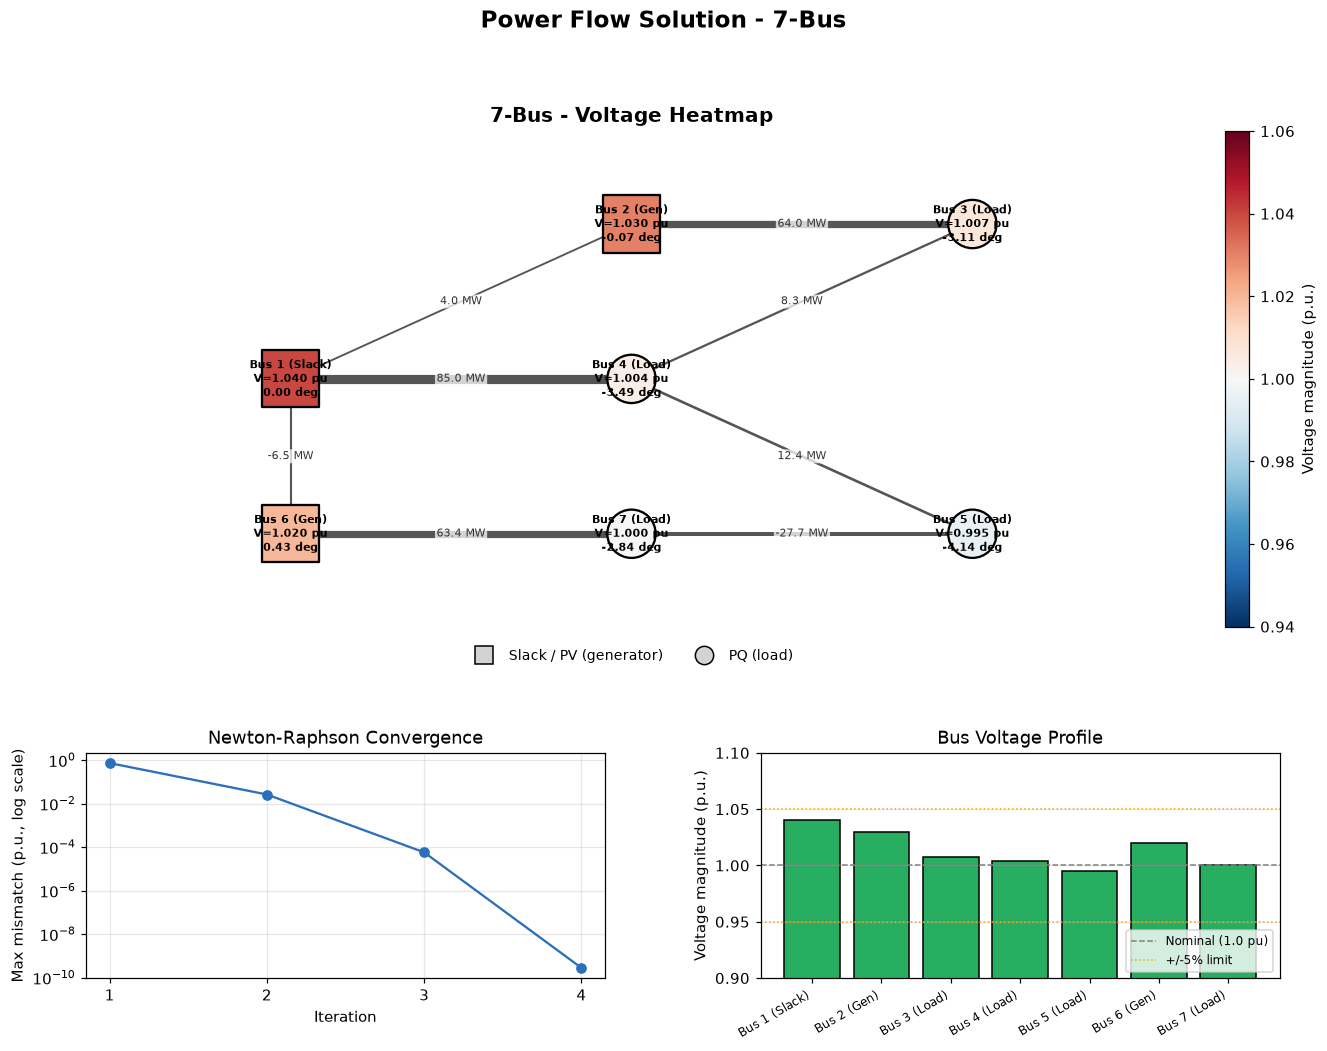

saved fig_basecase.png


In [18]:
netf = base_network()
resf = run(netf)

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2.2, 1], hspace=0.35, wspace=0.3)

plot_network_heatmap(netf, resf, ax=fig.add_subplot(gs[0, :]))
plot_convergence(resf, ax=fig.add_subplot(gs[1, 0]))
plot_voltage_profile(netf, ax=fig.add_subplot(gs[1, 1]))

fig.suptitle(f"Power Flow Solution - {netf.name}", fontsize=15, fontweight='bold', y=0.99)
fig.savefig("fig_basecase.png", dpi=150, bbox_inches='tight')
plt.show()
print("saved fig_basecase.png")

## 12. The Jacobian at a solved point

For Figure 2 panel (b) we need the Jacobian **after** convergence, but `solve()`
builds it internally and throws it away. So we rebuild it here using the same
formulas, then take its singular values.

The smallest singular value is a health measure: large = healthy, **zero = collapse**.

In [19]:
def jacobian_at_solution(net):
    """Rebuild the Jacobian at the converged operating point."""
    G, B = net.Ybus.real, net.Ybus.imag
    pv_pq = sorted([b.id for b in net.buses if b.type in ('PV', 'PQ')])
    pq = sorted([b.id for b in net.buses if b.type == 'PQ'])
    V = np.array([b.V for b in net.buses])
    th = np.array([b.theta for b in net.buses])
    P = np.array([b.P_calc for b in net.buses])
    Q = np.array([b.Q_calc for b in net.buses])

    J11 = np.zeros((len(pv_pq), len(pv_pq)))
    J12 = np.zeros((len(pv_pq), len(pq)))
    J21 = np.zeros((len(pq), len(pv_pq)))
    J22 = np.zeros((len(pq), len(pq)))

    for a, i in enumerate(pv_pq):
        for b_, k in enumerate(pv_pq):
            if i == k:
                J11[a, b_] = -Q[i] - B[i, i] * V[i] ** 2
            else:
                ang = th[i] - th[k]
                J11[a, b_] = V[i]*V[k]*(G[i, k]*np.sin(ang) - B[i, k]*np.cos(ang))
        for b_, k in enumerate(pq):
            if i == k:
                J12[a, b_] = P[i]/V[i] + G[i, i]*V[i]
            else:
                ang = th[i] - th[k]
                J12[a, b_] = V[i]*(G[i, k]*np.cos(ang) + B[i, k]*np.sin(ang))

    for a, i in enumerate(pq):
        for b_, k in enumerate(pv_pq):
            if i == k:
                J21[a, b_] = P[i] - G[i, i]*V[i]**2
            else:
                ang = th[i] - th[k]
                J21[a, b_] = -V[i]*V[k]*(G[i, k]*np.cos(ang) + B[i, k]*np.sin(ang))
        for b_, k in enumerate(pq):
            if i == k:
                J22[a, b_] = Q[i]/V[i] - B[i, i]*V[i]
            else:
                ang = th[i] - th[k]
                J22[a, b_] = V[i]*(G[i, k]*np.sin(ang) - B[i, k]*np.cos(ang))

    return np.block([[J11, J12], [J21, J22]])

print("jacobian_at_solution ready")

jacobian_at_solution ready


### Continuation sweep

Walk lambda upward, recording voltage and Jacobian health at each step. Fine steps
near the collapse point where things change fast. Takes a few seconds.

In [20]:
lams, vmins, smins, conds, losslist = [], [], [], [], []

lam = 1.0
while lam <= 5.16:
    nl = scaled(lam)
    r = run(nl, max_iter=80)
    if r["converged"]:
        J = jacobian_at_solution(nl)
        sv = np.linalg.svd(J, compute_uv=False)
        lams.append(lam)
        vmins.append(min(b.V for b in nl.buses))
        smins.append(sv.min())
        conds.append(sv.max() / sv.min())
        losslist.append(losses(nl))
    lam += 0.05 if lam > 4.4 else 0.25

print(f"{len(lams)} solved points, lambda from {lams[0]:.2f} to {lams[-1]:.2f}")
print(f"sigma_min(J):  {smins[0]:.3f}  ->  {smins[-1]:.4f}")
print(f"cond(J):       {conds[0]:.1f}  ->  {conds[-1]:.1f}")

28 solved points, lambda from 1.00 to 5.15
sigma_min(J):  4.678  ->  0.0942
cond(J):       10.1  ->  318.4


### Find the exact collapse point

Bisection: repeatedly halve the interval between "converges" and "doesn't."

In [21]:
lo, hi = 5.0, 5.6
for _ in range(14):
    mid = (lo + hi) / 2
    if run(scaled(mid), max_iter=80)["converged"]:
        lo = mid
    else:
        hi = mid

lam_star = lo
total_base_load = sum(pd for pd, _ in BASE_LOADS.values()) * 100
print(f"Maximum loadability lambda* = {lam_star:.4f}")
print(f"  base load:       {total_base_load:.0f} MW")
print(f"  load at collapse:{total_base_load*lam_star:.0f} MW")
print(f"  margin:          {(lam_star-1)*100:.0f}% above base")

ncrit = scaled(lam_star)
run(ncrit, max_iter=80)
Jc = np.linalg.svd(jacobian_at_solution(ncrit), compute_uv=False)
print(f"  at lambda*: Vmin={min(b.V for b in ncrit.buses):.4f} pu, "
      f"sigma_min={Jc.min():.5f}, cond={Jc.max()/Jc.min():.1f}")

Maximum loadability lambda* = 5.1513
  base load:       210 MW
  load at collapse:1082 MW
  margin:          415% above base
  at lambda*: Vmin=0.5511 pu, sigma_min=0.01115, cond=2668.8


## 13. FIGURE 2 - Nose curve, Jacobian singularity, convergence

The three-panel figure from the paper. Panel (b) is the important one: the Jacobian's
smallest singular value falling to zero at exactly the load where the solver fails.
**That is voltage collapse.**

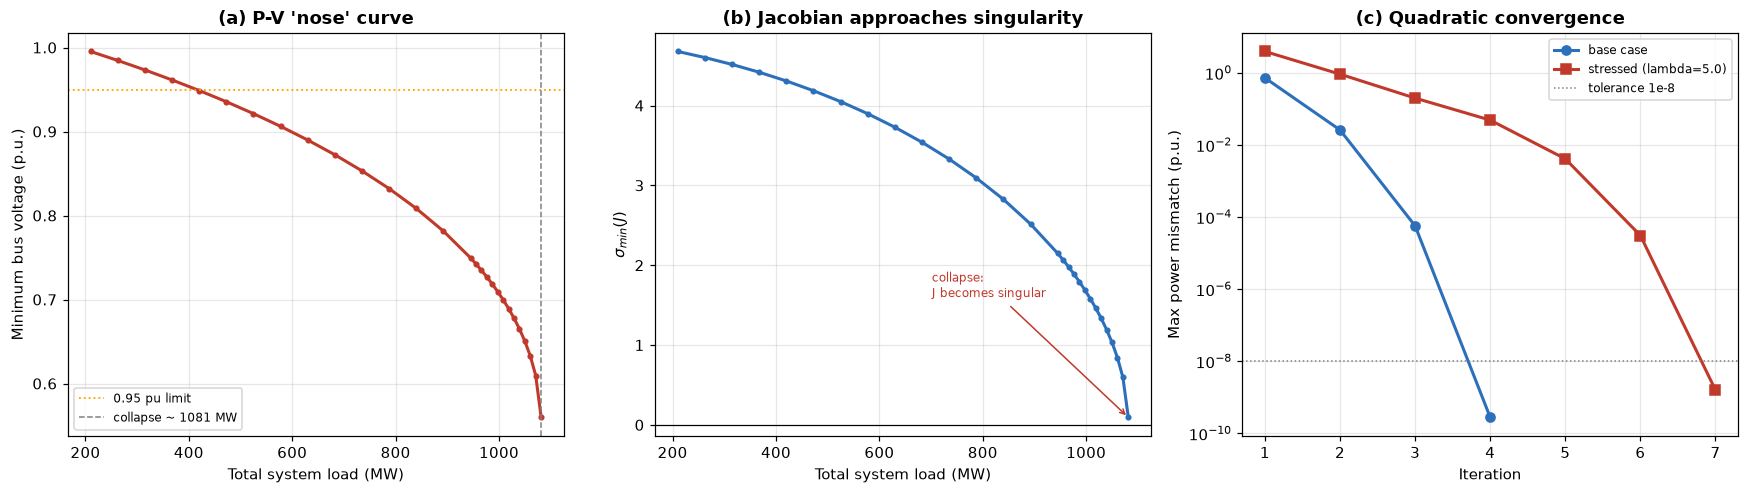

saved fig_analysis.png | collapse load = 1081.5 MW, sigma_min at end = 0.0942


In [22]:
loads = [l * total_base_load for l in lams]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) P-V nose curve
ax = axes[0]
ax.plot(loads, vmins, marker='o', ms=3, color="#c0392b", lw=2)
ax.axhline(0.95, color='orange', ls=':', lw=1.2, label='0.95 pu limit')
ax.axvline(loads[-1], color='gray', ls='--', lw=1, label=f'collapse ~ {loads[-1]:.0f} MW')
ax.set_xlabel("Total system load (MW)")
ax.set_ylabel("Minimum bus voltage (p.u.)")
ax.set_title("(a) P-V 'nose' curve", fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (b) Jacobian smallest singular value
ax = axes[1]
ax.plot(loads, smins, marker='o', ms=3, color="#2c6fbb", lw=2)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel("Total system load (MW)")
ax.set_ylabel(r"$\sigma_{min}(J)$")
ax.set_title("(b) Jacobian approaches singularity", fontweight='bold')
ax.grid(alpha=0.3)
ax.annotate("collapse:\nJ becomes singular",
            xy=(loads[-1], smins[-1]), xytext=(loads[-1]-380, 1.6),
            arrowprops=dict(arrowstyle='->', color='#c0392b'),
            fontsize=8, color='#c0392b')

# (c) convergence: healthy vs stressed
ax = axes[2]
hb = run(base_network())["mismatch_history"]
hs = run(scaled(5.0), max_iter=60)["mismatch_history"]
ax.semilogy(range(1, len(hb)+1), hb, marker='o', color="#2c6fbb", lw=2,
            label="base case")
ax.semilogy(range(1, len(hs)+1), hs, marker='s', color="#c0392b", lw=2,
            label="stressed (lambda=5.0)")
ax.axhline(1e-8, color='gray', ls=':', lw=1, label='tolerance 1e-8')
ax.set_xlabel("Iteration")
ax.set_ylabel("Max power mismatch (p.u.)")
ax.set_title("(c) Quadratic convergence", fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
fig.savefig("fig_analysis.png", dpi=160, bbox_inches='tight')
plt.show()
print(f"saved fig_analysis.png | collapse load = {loads[-1]:.1f} MW, "
      f"sigma_min at end = {smins[-1]:.4f}")

## 14. Bonus figures

Two extra plots that visualize experiments the paper only reported as tables.

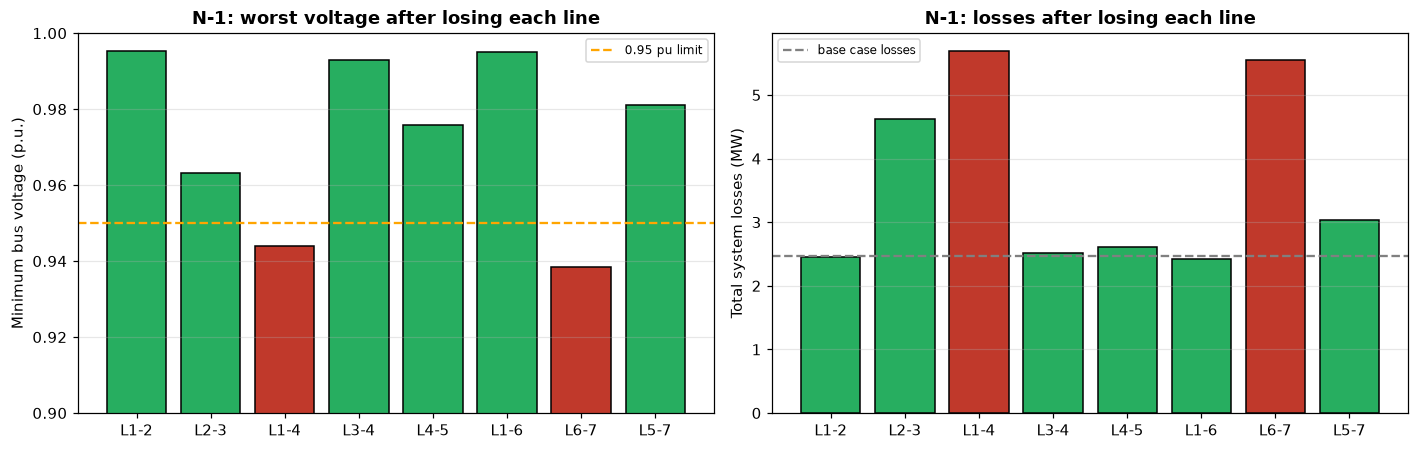

In [23]:
# BONUS 1: N-1 contingency screen as a chart
names = [r[0] for r in n1_results]
vmins_n1 = [r[1] for r in n1_results]
viol = [r[3] for r in n1_results]
colors = ["#c0392b" if v else "#27ae60" for v in viol]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))

a1.bar(names, vmins_n1, color=colors, edgecolor='black')
a1.axhline(0.95, color='orange', ls='--', lw=1.5, label='0.95 pu limit')
a1.set_ylim(0.90, 1.0)
a1.set_ylabel("Minimum bus voltage (p.u.)")
a1.set_title("N-1: worst voltage after losing each line", fontweight='bold')
a1.legend(fontsize=8)
a1.grid(axis='y', alpha=0.3)

a2.bar(names, [r[2] for r in n1_results], color=colors, edgecolor='black')
a2.axhline(losses(net), color='gray', ls='--', lw=1.5, label='base case losses')
a2.set_ylabel("Total system losses (MW)")
a2.set_title("N-1: losses after losing each line", fontweight='bold')
a2.legend(fontsize=8)
a2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig("fig_n1.png", dpi=150, bbox_inches='tight')
plt.show()

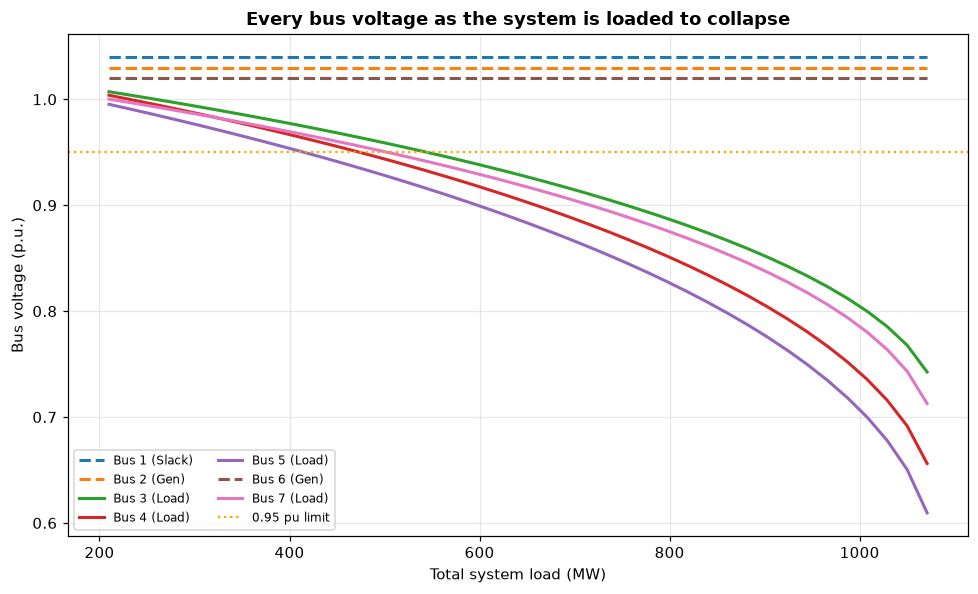

Dashed = generator/slack buses (held at setpoint). Solid = load buses (sag).


In [24]:
# BONUS 2: every bus voltage as load scales up
bus_tracks = {b.name: [] for b in base_network().buses}
track_lams = []
for lam in np.arange(1.0, 5.16, 0.1):
    nl = scaled(lam)
    if run(nl, max_iter=80)["converged"]:
        track_lams.append(lam)
        for b in nl.buses:
            bus_tracks[b.name].append(b.V)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, vs in bus_tracks.items():
    style = '--' if 'Slack' in name or 'Gen' in name else '-'
    ax.plot([l*total_base_load for l in track_lams], vs, style, lw=2, label=name)
ax.axhline(0.95, color='orange', ls=':', lw=1.5, label='0.95 pu limit')
ax.set_xlabel("Total system load (MW)")
ax.set_ylabel("Bus voltage (p.u.)")
ax.set_title("Every bus voltage as the system is loaded to collapse", fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("fig_bus_tracks.png", dpi=150, bbox_inches='tight')
plt.show()

print("Dashed = generator/slack buses (held at setpoint). Solid = load buses (sag).")

---

## Making your own experiments

`base_network()` takes three kinds of patch:

```python
base_network(bus={3: dict(Pd=1.60)})           # bus 3's load -> 160 MW
base_network(branch={"L1-4": dict(x=0.240)})   # L1-4 reactance -> 0.240
base_network(drop_branch="L1-4")               # remove L1-4 entirely
```

Bus indices are **0-based** (bus 3 in code = "Bus 4" in the labels). Then:

```python
n = base_network(bus={3: dict(Pd=1.20)})
run(n)
print(dict(zip(HDR, vrow(n))), losses(n))
plot_network_heatmap(n); plt.show()
```